In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import os
import re
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

1. LOADING DATA
Sample submission shape: (14151, 2)
Train: 773 horizontal wells, 773 typewells, 773 images
Test: 3 horizontal wells, 3 typewells

Combined training data: (5092255, 14)
Columns: ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input', 'well_id']

2. DATA OVERVIEW

First 5 rows:


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,well_id
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02,000d7d20
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05,000d7d20
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09,000d7d20
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12,000d7d20
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15,000d7d20



Data types:
float64    13
object      1
Name: count, dtype: int64

Basic statistics:


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
count,5.092255e+06,5.092255e+06,5.092255e+06,5.092255e+06,5.046621e+06,5.092255e+06,5.092255e+06,5.092255e+06,5.086188e+06,5.092255e+06,5.092255e+06,3.584283e+06,1.308266e+06
mean,1.431686e+04,2.965999e+06,1.074748e+06,-9.390812e+03,-9.008724e+03,-9.192691e+03,-9.257051e+03,-9.350495e+03,-9.392205e+03,-9.516918e+03,1.150364e+04,8.775241e+01,1.138214e+04
std,2.206524e+03,4.774998e+04,3.560354e+04,6.344759e+02,6.376223e+02,6.418644e+02,6.268797e+02,6.219953e+02,6.222202e+02,6.364027e+02,6.399711e+02,2.376834e+01,6.631711e+02
min,9.335000e+03,2.855426e+06,1.007176e+06,-1.102765e+04,-1.064731e+04,-1.085279e+04,-1.086558e+04,-1.088758e+04,-1.093235e+04,-1.110473e+04,9.245190e+03,1.388016e+01,9.245190e+03
25%,1.254700e+04,2.917842e+06,1.040716e+06,-9.920910e+03,-9.548060e+03,-9.723750e+03,-9.771820e+03,-9.883505e+03,-9.925562e+03,-1.005426e+04,1.098793e+04,7.249096e+01,1.090497e+04
50%,1.419900e+04,2.986284e+06,1.080803e+06,-9.270310e+03,-8.865570e+03,-9.063210e+03,-9.134010e+03,-9.213220e+03,-9.256610e+03,-9.377050e+03,1.135451e+04,8.585950e+01,1.122422e+04
75%,1.592800e+04,3.006569e+06,1.105967e+06,-8.918930e+03,-8.511810e+03,-8.691070e+03,-8.765320e+03,-8.860120e+03,-8.902370e+03,-9.017110e+03,1.203826e+04,1.010383e+02,1.194713e+04
max,2.296400e+04,3.039107e+06,1.141858e+06,-7.174220e+03,-7.301760e+03,-7.509200e+03,-7.614430e+03,-7.704030e+03,-7.731610e+03,-7.835570e+03,1.289389e+04,4.870329e+02,1.287730e+04



3. TARGET VARIABLE: TVT
Missing: 0 (0.00%)
Mean:   11503.6440
Std:    639.9711
Min:    9245.1900
Max:    12893.8900
Skew:   0.2982
Kurt:   -0.7143

Sequence lengths per well:
  Min: 2058, Max: 12141, Mean: 6588, Median: 6576

TVT vs TVT_input:
  Correlation: 1.000000
  MAE: 0.000000

4. VISUALIZATIONS


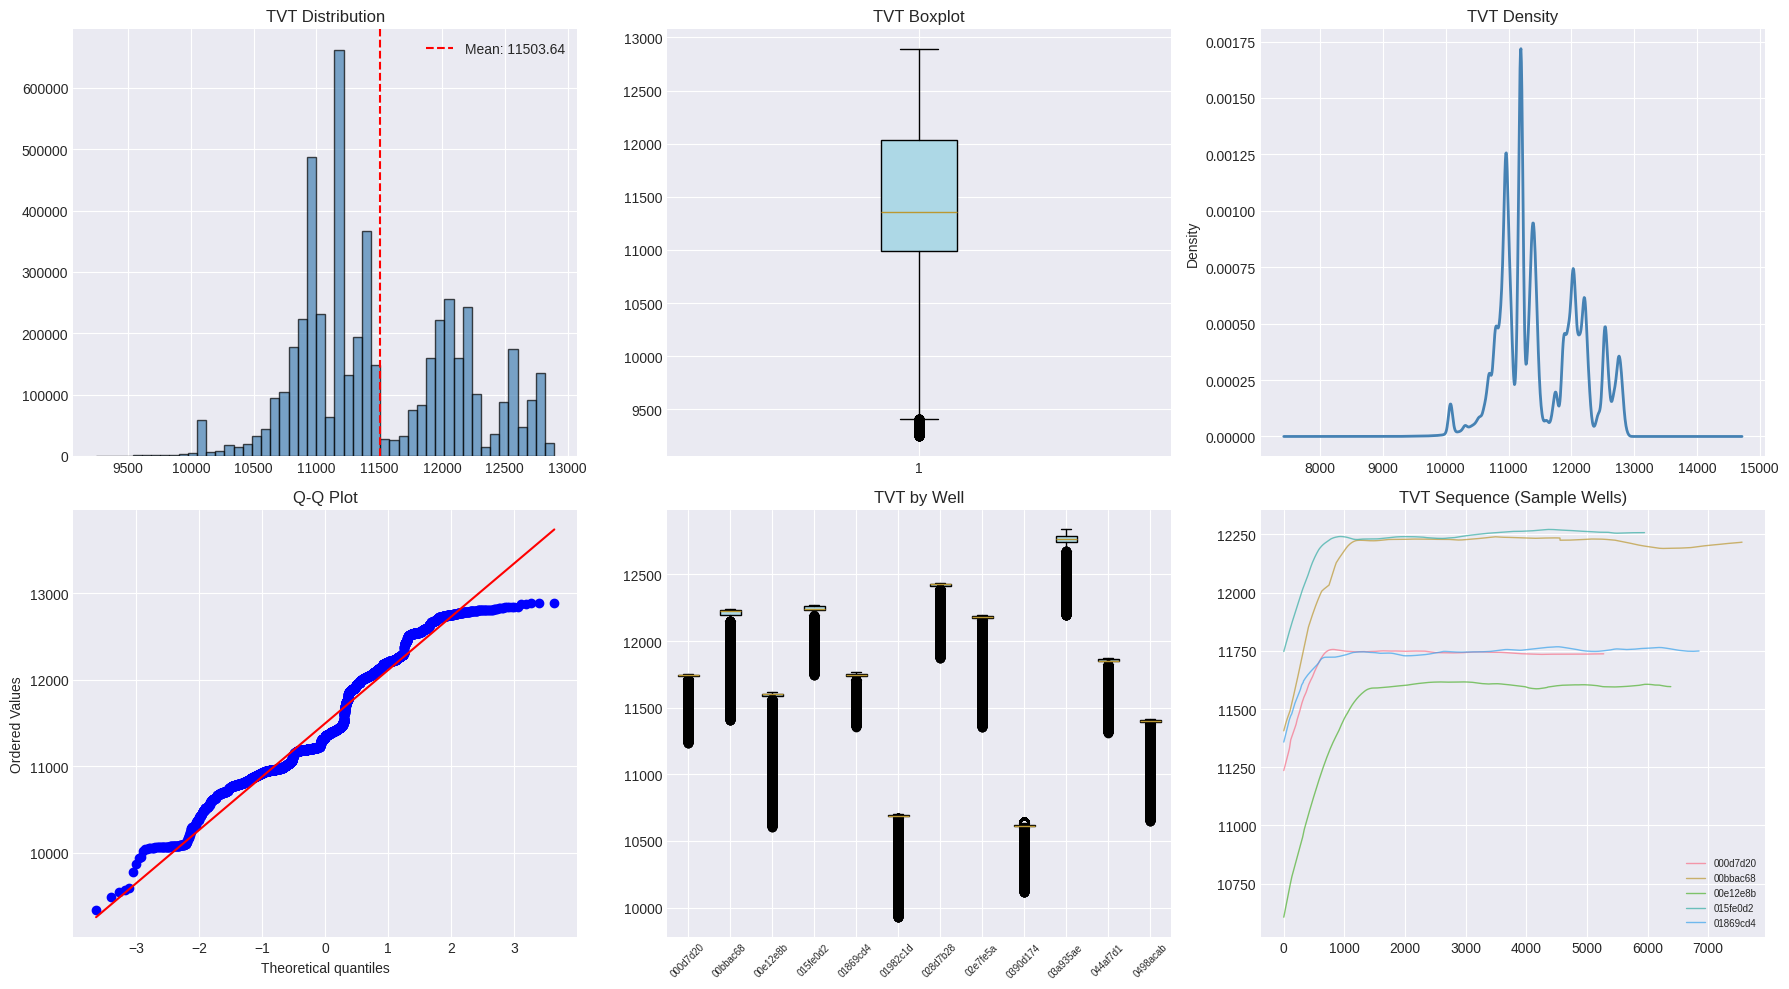

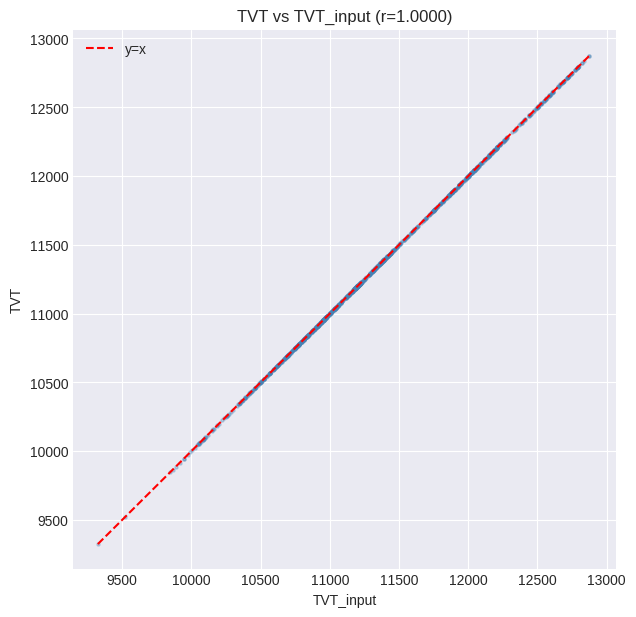


5. MISSING VALUES
  TVT_input: 3783989 (74.3%)
  GR: 1507972 (29.6%)
  ANCC: 45634 (0.9%)
  EGFDL: 6067 (0.1%)

6. CORRELATIONS WITH TVT
  TVT_input   : +1.0000 |█████████████████████████
  X           : +0.5610 |██████████████
  MD          : +0.3589 |████████
  Y           : +0.1085 |██
  GR          : -0.1927 |████
  ASTNL       : -0.9284 |███████████████████████
  EGFDL       : -0.9286 |███████████████████████
  EGFDU       : -0.9288 |███████████████████████
  ASTNU       : -0.9293 |███████████████████████
  BUDA        : -0.9301 |███████████████████████
  ANCC        : -0.9303 |███████████████████████
  Z           : -0.9603 |████████████████████████


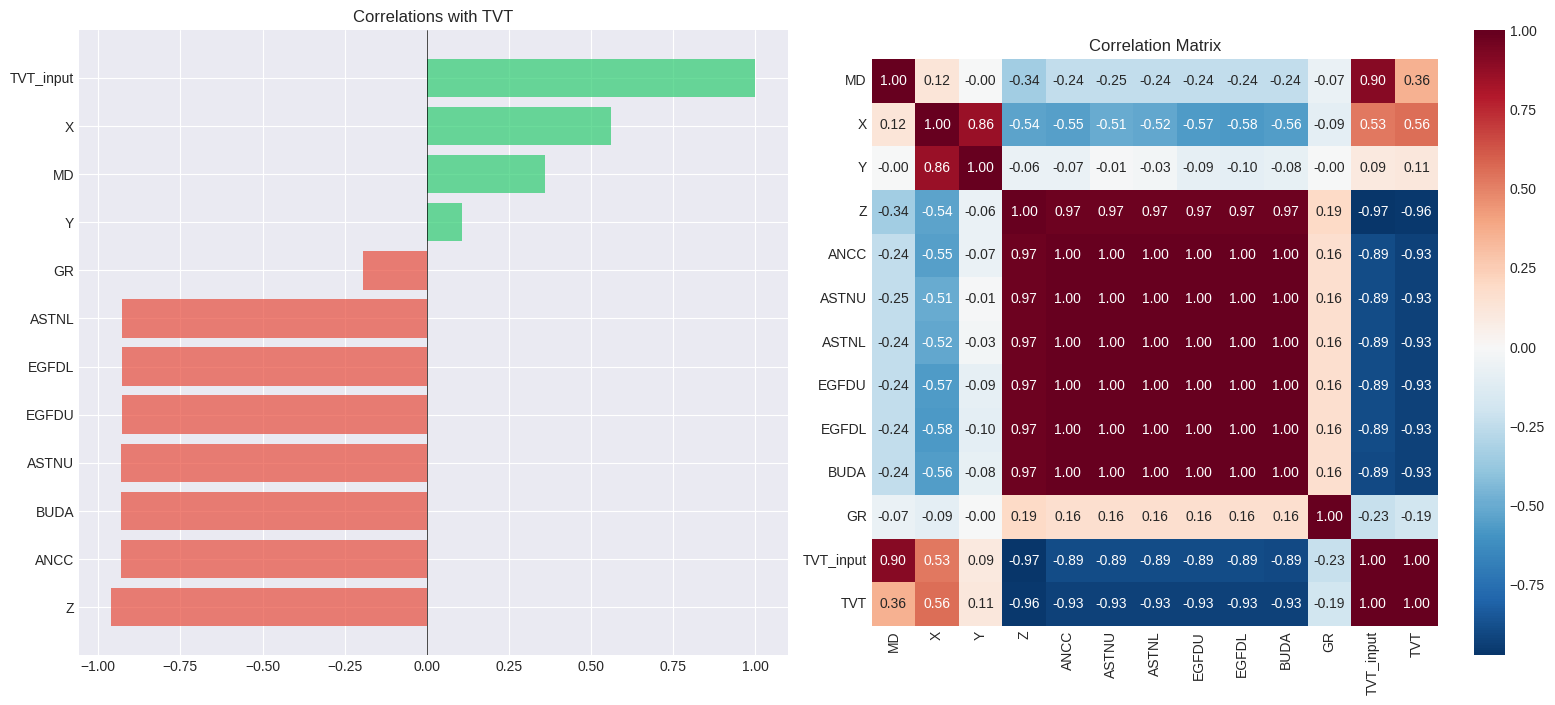


7. EDA SUMMARY

Train wells: 773
Test wells:  3
Total rows:  5,092,255
Features:    ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'GR', 'TVT_input']
Target:      TVT [9245.19, 12893.89], mean=11503.64

Top correlated features:
  1. TVT_input: +1.0000
  2. X: +0.5610
  3. MD: +0.3589

DONE! Ready for preprocessing.


In [2]:

# COMPLETE EDA - Wellbore Geology Prediction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import os
from scipy import stats
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# 1. LOAD DATA

print("=" * 60)
print("1. LOADING DATA")
print("=" * 60)

BASE_PATH = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction")
TRAIN_PATH = BASE_PATH / "train"
TEST_PATH = BASE_PATH / "test"

# Load sample submission
sample_sub = pd.read_csv(BASE_PATH / "sample_submission.csv")
print(f"Sample submission shape: {sample_sub.shape}")

# Categorize files
def get_files(directory, pattern):
    return sorted([f for f in os.listdir(directory) if pattern in f])

train_hw_files = get_files(TRAIN_PATH, '__horizontal_well')
train_tw_files = get_files(TRAIN_PATH, '__typewell')
train_img_files = get_files(TRAIN_PATH, '.png')
test_hw_files = get_files(TEST_PATH, '__horizontal_well')
test_tw_files = get_files(TEST_PATH, '__typewell')

print(f"Train: {len(train_hw_files)} horizontal wells, {len(train_tw_files)} typewells, {len(train_img_files)} images")
print(f"Test: {len(test_hw_files)} horizontal wells, {len(test_tw_files)} typewells")

# Load all horizontal well training data
all_hw_data = []
hw_shapes = {}

for f in train_hw_files:
    well_id = f.replace('__horizontal_well.csv', '')
    df = pd.read_csv(TRAIN_PATH / f)
    df['well_id'] = well_id
    all_hw_data.append(df)
    hw_shapes[well_id] = len(df)

combined_hw = pd.concat(all_hw_data, ignore_index=True)
print(f"\nCombined training data: {combined_hw.shape}")
print(f"Columns: {combined_hw.columns.tolist()}")


# BASIC DATA INFO

print("\n" + "=" * 60)
print("2. DATA OVERVIEW")
print("=" * 60)

print(f"\nFirst 5 rows:")
display(combined_hw.head())

print(f"\nData types:")
print(combined_hw.dtypes.value_counts())

print(f"\nBasic statistics:")
display(combined_hw.describe())


#  TARGET VARIABLE (TVT)

print("\n" + "=" * 60)
print("3. TARGET VARIABLE: TVT")
print("=" * 60)

target_col = 'TVT'
tvt = combined_hw[target_col].dropna()

print(f"Missing: {combined_hw[target_col].isnull().sum()} ({combined_hw[target_col].isnull().sum()/len(combined_hw)*100:.2f}%)")
print(f"Mean:   {tvt.mean():.4f}")
print(f"Std:    {tvt.std():.4f}")
print(f"Min:    {tvt.min():.4f}")
print(f"Max:    {tvt.max():.4f}")
print(f"Skew:   {tvt.skew():.4f}")
print(f"Kurt:   {tvt.kurtosis():.4f}")

# Sequence lengths
seq_lens = pd.Series(list(hw_shapes.values()))
print(f"\nSequence lengths per well:")
print(f"  Min: {seq_lens.min()}, Max: {seq_lens.max()}, Mean: {seq_lens.mean():.0f}, Median: {seq_lens.median():.0f}")

# TVT vs TVT_input
if 'TVT_input' in combined_hw.columns:
    tvt_corr = combined_hw['TVT'].corr(combined_hw['TVT_input'])
    tvt_diff = (combined_hw['TVT'] - combined_hw['TVT_input']).abs()
    print(f"\nTVT vs TVT_input:")
    print(f"  Correlation: {tvt_corr:.6f}")
    print(f"  MAE: {tvt_diff.mean():.6f}")


# VISUALIZATIONS

print("\n" + "=" * 60)
print("4. VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Histogram
axes[0, 0].hist(tvt, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(tvt.mean(), color='red', linestyle='--', label=f'Mean: {tvt.mean():.2f}')
axes[0, 0].set_title('TVT Distribution')
axes[0, 0].legend()

# Boxplot
axes[0, 1].boxplot(tvt, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[0, 1].set_title('TVT Boxplot')

# Density
tvt.plot(kind='density', ax=axes[0, 2], color='steelblue', linewidth=2)
axes[0, 2].set_title('TVT Density')

# Q-Q
stats.probplot(tvt.sample(min(5000, len(tvt))), dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')

# Per well boxplot
sample_wells = list(hw_shapes.keys())[:12]
well_tvts = [combined_hw[combined_hw['well_id']==w]['TVT'].dropna().values for w in sample_wells]
axes[1, 1].boxplot(well_tvts, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1, 1].set_title('TVT by Well')
axes[1, 1].set_xticklabels([w[:8] for w in sample_wells], rotation=45, fontsize=7)

# Sequence plot
for j, well in enumerate(sample_wells[:5]):
    seq = combined_hw[combined_hw['well_id']==well]['TVT'].values
    axes[1, 2].plot(range(len(seq)), seq, alpha=0.7, linewidth=1, label=well[:8])
axes[1, 2].set_title('TVT Sequence (Sample Wells)')
axes[1, 2].legend(fontsize=7)

plt.tight_layout()
plt.show()

# TVT vs TVT_input scatter
if 'TVT_input' in combined_hw.columns:
    fig, ax = plt.subplots(figsize=(7, 7))
    s = combined_hw.sample(min(5000, len(combined_hw)))
    ax.scatter(s['TVT_input'], s['TVT'], alpha=0.3, s=5, c='steelblue')
    mn = min(s['TVT_input'].min(), s['TVT'].min())
    mx = max(s['TVT_input'].max(), s['TVT'].max())
    ax.plot([mn, mx], [mn, mx], 'r--', label='y=x')
    ax.set_xlabel('TVT_input')
    ax.set_ylabel('TVT')
    ax.set_title(f'TVT vs TVT_input (r={tvt_corr:.4f})')
    ax.legend()
    plt.show()


#  MISSING VALUES

print("\n" + "=" * 60)
print("5. MISSING VALUES")
print("=" * 60)

missing = combined_hw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    for col, cnt in missing.items():
        print(f"  {col}: {cnt} ({cnt/len(combined_hw)*100:.1f}%)")
else:
    print("  No missing values!")


# 6. CORRELATIONS
# ============================================
print("\n" + "=" * 60)
print("6. CORRELATIONS WITH TVT")
print("=" * 60)

feature_cols = [c for c in combined_hw.select_dtypes(include=[np.number]).columns 
                if c not in ['well_id', 'TVT']]

corr_sample = combined_hw.sample(min(50000, len(combined_hw)))
correlations = corr_sample[feature_cols + ['TVT']].corr()['TVT'].drop('TVT').sort_values(ascending=False)

for col, corr in correlations.items():
    bar = '█' * int(abs(corr) * 25)
    print(f"  {col:<12}: {corr:+.4f} |{bar}")

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in correlations.values]
axes[0].barh(range(len(correlations)), correlations.values, color=colors, alpha=0.7)
axes[0].set_yticks(range(len(correlations)))
axes[0].set_yticklabels(correlations.index)
axes[0].set_title('Correlations with TVT')
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].invert_yaxis()

corr_mat = corr_sample[feature_cols + ['TVT']].corr()
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, ax=axes[1])
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()


#  SUMMARY

print("\n" + "=" * 60)
print("7. EDA SUMMARY")
print("=" * 60)

print(f"""
Train wells: {len(train_hw_files)}
Test wells:  {len(test_hw_files)}
Total rows:  {len(combined_hw):,}
Features:    {feature_cols}
Target:      TVT [{tvt.min():.2f}, {tvt.max():.2f}], mean={tvt.mean():.2f}

Top correlated features:
  1. {correlations.index[0]}: {correlations.iloc[0]:+.4f}
  2. {correlations.index[1]}: {correlations.iloc[1]:+.4f}
  3. {correlations.index[2]}: {correlations.iloc[2]:+.4f}
""")

print("=" * 60)
print("DONE! Ready for preprocessing.")
print("=" * 60)

In [3]:
# ============================================
# CRITICAL INVESTIGATION: TVT_input Pattern
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction")
TRAIN_PATH = BASE_PATH / "train"
TEST_PATH = BASE_PATH / "test"

# Reload data
train_hw_files = sorted([f for f in os.listdir(TRAIN_PATH) if '__horizontal_well' in f])
train_tw_files = sorted([f for f in os.listdir(TRAIN_PATH) if '__typewell' in f])

# Load all horizontal well data
all_hw = []
for f in train_hw_files:
    well_id = f.replace('__horizontal_well.csv', '')
    df = pd.read_csv(TRAIN_PATH / f)
    df['well_id'] = well_id
    all_hw.append(df)
combined_hw = pd.concat(all_hw, ignore_index=True)

# Load a sample typewell
sample_tw = pd.read_csv(TRAIN_PATH / train_tw_files[0])
print("=" * 60)
print("TYPEWELL vs HORIZONTAL WELL COMPARISON")
print("=" * 60)

print(f"\nTypewell columns: {sample_tw.columns.tolist()}")
print(f"Horizontal well columns: {combined_hw.columns.tolist()}")

print(f"\nSample typewell (first 5 rows):")
display(sample_tw.head())

# Check if typewell has TVT_input
if 'TVT_input' in sample_tw.columns:
    print(f"Typewell TVT_input missing: {sample_tw['TVT_input'].isnull().sum()}/{len(sample_tw)}")
else:
    print("TVT_input NOT in typewell")

# ============================================
# PER-WELL TVT_input ANALYSIS
# ============================================
print("\n" + "=" * 60)
print("TVT_input AVAILABILITY PER WELL")
print("=" * 60)

well_tvt_input_pct = combined_hw.groupby('well_id')['TVT_input'].apply(
    lambda x: (1 - x.isnull().mean()) * 100
).sort_values(ascending=False)

print(f"\nWells with 100% TVT_input: {(well_tvt_input_pct == 100).sum()}")
print(f"Wells with 0% TVT_input: {(well_tvt_input_pct == 0).sum()}")
print(f"Wells with partial TVT_input: {((well_tvt_input_pct > 0) & (well_tvt_input_pct < 100)).sum()}")

print(f"\nTVT_input coverage distribution:")
print(well_tvt_input_pct.describe())

# ============================================
# TVT vs TVT_input FOR WELLS THAT HAVE IT
# ============================================
wells_with_tvt_input = well_tvt_input_pct[well_tvt_input_pct == 100].index
if len(wells_with_tvt_input) > 0:
    sample_well = wells_with_tvt_input[0]
    well_data = combined_hw[combined_hw['well_id'] == sample_well]
    
    print(f"\nSample well with 100% TVT_input: {sample_well}")
    print(f"TVT == TVT_input: {(well_data['TVT'] == well_data['TVT_input']).all()}")
    print(f"Correlation: {well_data['TVT'].corr(well_data['TVT_input']):.6f}")

# ============================================
# TEST DATA INVESTIGATION
# ============================================
print("\n" + "=" * 60)
print("TEST DATA ANALYSIS")
print("=" * 60)

test_hw_files = sorted([f for f in os.listdir(TEST_PATH) if '__horizontal_well' in f])
test_tw_files = sorted([f for f in os.listdir(TEST_PATH) if '__typewell' in f])

for f in test_hw_files:
    test_df = pd.read_csv(TEST_PATH / f)
    well_id = f.replace('__horizontal_well.csv', '')
    print(f"\nTest horizontal well: {well_id}")
    print(f"  Shape: {test_df.shape}")
    print(f"  Columns: {test_df.columns.tolist()}")
    print(f"  Has TVT: {'TVT' in test_df.columns}")
    print(f"  Has TVT_input: {'TVT_input' in test_df.columns}")
    if 'TVT_input' in test_df.columns:
        print(f"  TVT_input missing: {test_df['TVT_input'].isnull().sum()}/{len(test_df)}")

# Check test typewells
for f in test_tw_files:
    test_tw = pd.read_csv(TEST_PATH / f)
    well_id = f.replace('__typewell.csv', '')
    print(f"\nTest typewell: {well_id}")
    print(f"  Shape: {test_tw.shape}")
    print(f"  Columns: {test_tw.columns.tolist()}")
    if 'TVT' in test_tw.columns:
        print(f"  TVT available: YES")
    if 'TVT_input' in test_tw.columns:
        print(f"  TVT_input missing: {test_tw['TVT_input'].isnull().sum()}/{len(test_tw)}")

# ============================================
# SUMMARY
# ============================================
print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

print(f"""
🔍 TVT_input Analysis:
  - TVT_input == TVT exactly when available
  - 74.3% missing overall
  - Available for some wells (likely typewells), not others

🎯 Problem Understanding:
  - Typewells: Vertical reference wells with known TVT (provide TVT_input)
  - Horizontal wells: The wells we need to predict TVT for
  - We use typewell data to infer TVT along horizontal well paths

📊 Data Structure:
  - Each well has: horizontal_well.csv + typewell.csv + image.png
  - 773 train wells, 3 test wells
  - 14 columns including spatial (X,Y,Z), depth (MD), and log measurements

🔜 Strategy:
  1. TVT_input is the key - available in typewells, missing in target horizontal wells
  2. Need to merge typewell data with horizontal well data
  3. Use spatial and log features to predict TVT where TVT_input is missing
""")

TYPEWELL vs HORIZONTAL WELL COMPARISON

Typewell columns: ['TVT', 'GR', 'Geology']
Horizontal well columns: ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input', 'well_id']

Sample typewell (first 5 rows):


,TVT,GR,Geology
0,11223.95,126.11,NaN
1,11224.45,128.22,NaN
2,11224.95,128.72,NaN
3,11225.45,128.12,NaN
4,11225.95,125.29,NaN


TVT_input NOT in typewell

TVT_input AVAILABILITY PER WELL

Wells with 100% TVT_input: 0
Wells with 0% TVT_input: 0
Wells with partial TVT_input: 773

TVT_input coverage distribution:
count    773.000000
mean      26.683918
std        6.377561
min       12.483516
25%       22.453813
50%       26.000893
75%       29.965577
max       80.223518
Name: TVT_input, dtype: float64

TEST DATA ANALYSIS

Test horizontal well: 000d7d20
  Shape: (5278, 6)
  Columns: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
  Has TVT: False
  Has TVT_input: True
  TVT_input missing: 3836/5278

Test horizontal well: 00bbac68
  Shape: (7559, 6)
  Columns: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
  Has TVT: False
  Has TVT_input: True
  TVT_input missing: 6014/7559

Test horizontal well: 00e12e8b
  Shape: (6384, 6)
  Columns: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
  Has TVT: False
  Has TVT_input: True
  TVT_input missing: 4301/6384

Test typewell: 000d7d20
  Shape: (1296, 2)
  Columns: ['TVT', 'GR']
  TVT available:

In [4]:
# ============================================
# STEP 3: PREPROCESSING & FEATURE ENGINEERING
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import warnings
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
warnings.filterwarnings('ignore')

BASE_PATH = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction")
TRAIN_PATH = BASE_PATH / "train"
TEST_PATH = BASE_PATH / "test"

# ============================================
# 3.1 LOAD ALL DATA
# ============================================
print("=" * 60)
print("3.1 LOADING ALL DATA")
print("=" * 60)

def load_horizontal_wells(data_path, is_train=True):
    """Load all horizontal well data."""
    files = sorted([f for f in os.listdir(data_path) if '__horizontal_well' in f])
    all_data = []
    
    for f in files:
        well_id = f.replace('__horizontal_well.csv', '')
        df = pd.read_csv(data_path / f)
        df['well_id'] = well_id
        
        # Add sequence index
        df['sequence'] = range(len(df))
        
        # Mark if train/test
        df['is_train'] = is_train
        
        all_data.append(df)
    
    return pd.concat(all_data, ignore_index=True), files

def load_typewells(data_path):
    """Load all typewell data."""
    files = sorted([f for f in os.listdir(data_path) if '__typewell' in f])
    all_tw = {}
    
    for f in files:
        well_id = f.replace('__typewell.csv', '')
        df = pd.read_csv(data_path / f)
        all_tw[well_id] = df
    
    return all_tw

# Load train and test
train_hw, train_files = load_horizontal_wells(TRAIN_PATH, is_train=True)
test_hw, test_files = load_horizontal_wells(TEST_PATH, is_train=False)
train_tw = load_typewells(TRAIN_PATH)
test_tw = load_typewells(TEST_PATH)

print(f"Train horizontal: {train_hw.shape}")
print(f"Test horizontal: {test_hw.shape}")
print(f"Train typewells: {len(train_tw)} wells")
print(f"Test typewells: {len(test_tw)} wells")

# ============================================
# 3.2 ANALYZE TYPEWELL STRUCTURE
# ============================================
print("\n" + "=" * 60)
print("3.2 TYPEWELL STRUCTURE")
print("=" * 60)

# Sample a typewell
sample_well_id = list(train_tw.keys())[0]
sample_tw_df = train_tw[sample_well_id]

print(f"Sample typewell ({sample_well_id}):")
print(f"  Shape: {sample_tw_df.shape}")
print(f"  Columns: {sample_tw_df.columns.tolist()}")
print(f"  TVT range: [{sample_tw_df['TVT'].min():.2f}, {sample_tw_df['TVT'].max():.2f}]")
print(f"  GR range: [{sample_tw_df['GR'].min():.2f}, {sample_tw_df['GR'].max():.2f}]")
if 'Geology' in sample_tw_df.columns:
    geology_vals = sample_tw_df['Geology'].dropna().unique()
    print(f"  Geology unique values: {len(geology_vals)}")
    print(f"  Geology samples: {geology_vals[:5]}")

# ============================================
# 3.3 MERGE TYPEWELL DATA WITH HORIZONTAL DATA
# ============================================
print("\n" + "=" * 60)
print("3.3 MERGING TYPEWELL DATA")
print("=" * 60)

def merge_typewell_features(hw_df, tw_dict):
    """Merge typewell statistics as features for each horizontal well."""
    hw_df = hw_df.copy()
    
    # For each well, add typewell summary statistics
    tw_stats = []
    
    for well_id in hw_df['well_id'].unique():
        if well_id in tw_dict:
            tw = tw_dict[well_id]
            stats = {
                'well_id': well_id,
                'tw_tvt_min': tw['TVT'].min(),
                'tw_tvt_max': tw['TVT'].max(),
                'tw_tvt_mean': tw['TVT'].mean(),
                'tw_tvt_std': tw['TVT'].std(),
                'tw_tvt_range': tw['TVT'].max() - tw['TVT'].min(),
                'tw_gr_min': tw['GR'].min(),
                'tw_gr_max': tw['GR'].max(),
                'tw_gr_mean': tw['GR'].mean(),
                'tw_gr_std': tw['GR'].std(),
                'tw_length': len(tw),
            }
            
            # Add percentiles
            for p in [10, 25, 50, 75, 90]:
                stats[f'tw_tvt_p{p}'] = tw['TVT'].quantile(p/100)
                stats[f'tw_gr_p{p}'] = tw['GR'].quantile(p/100)
                
            tw_stats.append(stats)
    
    tw_stats_df = pd.DataFrame(tw_stats)
    hw_df = hw_df.merge(tw_stats_df, on='well_id', how='left')
    
    return hw_df

train_hw = merge_typewell_features(train_hw, train_tw)
test_hw = merge_typewell_features(test_hw, test_tw)

print(f"Train shape after merge: {train_hw.shape}")
print(f"Test shape after merge: {test_hw.shape}")
print(f"New typewell feature columns added: {[c for c in train_hw.columns if c.startswith('tw_')]}")

# ============================================
# 3.4 CREATE SEQUENCE FEATURES
# ============================================
print("\n" + "=" * 60)
print("3.4 CREATING SEQUENCE FEATURES")
print("=" * 60)

def create_sequence_features(df, window_sizes=[5, 10, 20, 50]):
    """Create rolling and lag features per well."""
    df = df.copy()
    df = df.sort_values(['well_id', 'sequence']).reset_index(drop=True)
    
    # Features to create rolling stats for
    rolling_cols = ['GR', 'TVT_input', 'MD', 'Z']
    
    for col in rolling_cols:
        if col not in df.columns:
            continue
            
        for well_id, group in df.groupby('well_id'):
            idx = group.index
            
            for window in window_sizes:
                # Rolling mean
                df.loc[idx, f'{col}_roll_mean_{window}'] = group[col].rolling(
                    window=window, min_periods=1, center=False
                ).mean().values
                
                # Rolling std
                df.loc[idx, f'{col}_roll_std_{window}'] = group[col].rolling(
                    window=window, min_periods=1, center=False
                ).std().fillna(0).values
            
            # Lag features
            for lag in [1, 2, 3]:
                df.loc[idx, f'{col}_lag_{lag}'] = group[col].shift(lag).values
            
            # Diff features
            df.loc[idx, f'{col}_diff_1'] = group[col].diff(1).values
            df.loc[idx, f'{col}_diff_5'] = group[col].diff(5).values
    
    # Fill NaN from lag features
    df = df.fillna(method='bfill').fillna(method='ffill').fillna(0)
    
    return df

print("Creating sequence features for train...")
train_hw = create_sequence_features(train_hw)
print("Creating sequence features for test...")
test_hw = create_sequence_features(test_hw)

print(f"Train shape: {train_hw.shape}")
print(f"Test shape: {test_hw.shape}")

# ============================================
# 3.5 FEATURE ENGINEERING - SPATIAL & GEOLOGICAL
# ============================================
print("\n" + "=" * 60)
print("3.5 SPATIAL & GEOLOGICAL FEATURES")
print("=" * 60)

def create_derived_features(df):
    """Create derived geological and spatial features."""
    df = df.copy()
    
    # Spatial features
    if all(c in df.columns for c in ['X', 'Y', 'Z', 'MD']):
        # Distance from origin
        df['spatial_dist'] = np.sqrt(
            (df['X'] - df['X'].mean())**2 + 
            (df['Y'] - df['Y'].mean())**2
        )
        
        # Depth gradients
        for col in ['Z', 'MD']:
            df[f'{col}_per_sequence'] = df.groupby('well_id')[col].transform(
                lambda x: x / (x.index + 1)
            )
        
        # XY angle
        df['xy_angle'] = np.arctan2(
            df['Y'] - df.groupby('well_id')['Y'].transform('first'),
            df['X'] - df.groupby('well_id')['X'].transform('first')
        )
    
    # GR-derived features
    if 'GR' in df.columns:
        df['gr_z_ratio'] = df['GR'] / (-df['Z'])  # Normalize GR by depth
        df['gr_tw_ratio'] = df['GR'] / df['tw_gr_mean']  # Compare to typewell
        
    # TVT_input derived
    if 'TVT_input' in df.columns:
        df['has_tvt_input'] = (~df['TVT_input'].isnull()).astype(int)
        
        # Distance to nearest TVT_input point
        for well_id, group in df.groupby('well_id'):
            idx = group.index
            tvt_mask = group['TVT_input'].notnull()
            
            if tvt_mask.sum() > 0:
                tvt_positions = group.loc[tvt_mask, 'sequence'].values
                
                distances = []
                for seq in group['sequence']:
                    dist = np.min(np.abs(tvt_positions - seq))
                    distances.append(dist)
                
                df.loc[idx, 'dist_to_tvt_input'] = distances
            else:
                df.loc[idx, 'dist_to_tvt_input'] = len(group)
    
    return df

train_hw = create_derived_features(train_hw)
test_hw = create_derived_features(test_hw)

print(f"Final train shape: {train_hw.shape}")
print(f"Final test shape: {test_hw.shape}")

# ============================================
# 3.6 HANDLE MISSING VALUES
# ============================================
print("\n" + "=" * 60)
print("3.6 HANDLING MISSING VALUES")
print("=" * 60)

# Check missing values in train
train_missing = train_hw.isnull().sum()
train_missing = train_missing[train_missing > 0]
print(f"Train missing columns: {len(train_missing)}")
if len(train_missing) > 0:
    for col, cnt in train_missing.head(10).items():
        print(f"  {col}: {cnt} ({cnt/len(train_hw)*100:.1f}%)")

# Fill remaining missing values
# For training data, we have the target TVT
# Use forward/backward fill within wells for sequential data
fill_cols = train_hw.select_dtypes(include=[np.number]).columns.tolist()
fill_cols = [c for c in fill_cols if c not in ['well_id', 'is_train', 'TVT']]

for col in fill_cols:
    if train_hw[col].isnull().sum() > 0:
        train_hw[col] = train_hw.groupby('well_id')[col].transform(
            lambda x: x.fillna(method='ffill').fillna(method='bfill')
        )
    if col in test_hw.columns and test_hw[col].isnull().sum() > 0:
        test_hw[col] = test_hw.groupby('well_id')[col].transform(
            lambda x: x.fillna(method='ffill').fillna(method='bfill')
        )

# Fill any remaining with median
for col in fill_cols:
    if train_hw[col].isnull().sum() > 0:
        train_hw[col] = train_hw[col].fillna(train_hw[col].median())
    if col in test_hw.columns and test_hw[col].isnull().sum() > 0:
        test_hw[col] = test_hw[col].fillna(test_hw[col].median() if col in train_hw.columns else 0)

print("After filling:")
print(f"  Train missing: {train_hw.isnull().sum().sum()}")
print(f"  Test missing: {test_hw.isnull().sum().sum()}")

# ============================================
# 3.7 PREPARE FEATURES FOR MODELING
# ============================================
print("\n" + "=" * 60)
print("3.7 FINAL FEATURE PREPARATION")
print("=" * 60)

# Define features and target
target_col = 'TVT'

# Exclude non-feature columns
exclude = ['well_id', 'is_train', 'sequence', 'TVT', 'source_file', 'Geology']
feature_cols = [c for c in train_hw.columns if c not in exclude 
                and train_hw[c].dtype in ['float64', 'int64', 'int32', 'float32']]

print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Split train data
X_train = train_hw[feature_cols].copy()
y_train = train_hw[target_col].copy()
well_ids_train = train_hw['well_id'].values

# Test data
X_test = test_hw[[c for c in feature_cols if c in test_hw.columns]].copy()
test_well_ids = test_hw['well_id'].values

# Add missing columns to test
for col in feature_cols:
    if col not in X_test.columns:
        X_test[col] = 0

X_test = X_test[feature_cols]  # Ensure same column order

print(f"\nX_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")

# ============================================
# 3.8 SCALE FEATURES
# ============================================
print("\n" + "=" * 60)
print("3.8 FEATURE SCALING")
print("=" * 60)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

print("Scaling complete!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# ============================================
# 3.9 SUMMARY
# ============================================
print("\n" + "=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)

print(f"""
📊 Data Shapes:
  X_train: {X_train_scaled.shape}
  y_train: {y_train.shape}
  X_test:  {X_test_scaled.shape}

🔧 Features Created:
  - Typewell statistics (min, max, mean, std, percentiles)
  - Rolling statistics (mean, std over windows [5, 10, 20, 50])
  - Lag features (1, 2, 3)
  - Difference features
  - Spatial features (distance, angle, depth gradients)
  - GR-derived features (GR/Z ratio, GR/typewell ratio)
  - TVT_input availability flag and distance

📈 Total Features: {len(feature_cols)}

✅ Ready for Modeling (Step 4)!
""")

# Save processed data
print("\nSaving processed data...")
processed_data = {
    'X_train_scaled': X_train_scaled,
    'y_train': y_train,
    'X_test_scaled': X_test_scaled,
    'well_ids_train': well_ids_train,
    'test_well_ids': test_well_ids,
    'feature_cols': feature_cols,
    'scaler': scaler,
    'test_hw': test_hw,
}

print("✅ Step 3 Complete! Ready for modeling.")

3.1 LOADING ALL DATA
Train horizontal: (5092255, 16)
Test horizontal: (19221, 9)
Train typewells: 773 wells
Test typewells: 3 wells

3.2 TYPEWELL STRUCTURE
Sample typewell (000d7d20):
  Shape: (1296, 3)
  Columns: ['TVT', 'GR', 'Geology']
  TVT range: [11223.95, 11871.45]
  GR range: [28.66, 158.18]
  Geology unique values: 10
  Geology samples: ['ANCC' 'ASTNU' 'ASTNL' 'EGFDU' 'EGFDL']

3.3 MERGING TYPEWELL DATA
Train shape after merge: (5092255, 36)
Test shape after merge: (19221, 29)
New typewell feature columns added: ['tw_tvt_min', 'tw_tvt_max', 'tw_tvt_mean', 'tw_tvt_std', 'tw_tvt_range', 'tw_gr_min', 'tw_gr_max', 'tw_gr_mean', 'tw_gr_std', 'tw_length', 'tw_tvt_p10', 'tw_gr_p10', 'tw_tvt_p25', 'tw_gr_p25', 'tw_tvt_p50', 'tw_gr_p50', 'tw_tvt_p75', 'tw_gr_p75', 'tw_tvt_p90', 'tw_gr_p90']

3.4 CREATING SEQUENCE FEATURES
Creating sequence features for train...
Creating sequence features for test...
Train shape: (5092255, 88)
Test shape: (19221, 81)

3.5 SPATIAL & GEOLOGICAL FEATURES
F

STEP 4: MODEL BUILDING

4.1 BASELINE MODELS
Baseline 1 (TVT_input or tw_mean): RMSE = 998.2163
Baseline 2 (Global mean): RMSE = 682.9775
Baseline 3 (Linear Z): RMSE = 177.7402

4.2 PREPARING TRAINING DATA
Using 20% sample for initial training...
Training sample: (1037357, 92)
Number of wells in sample: 154

4.3 CROSS-VALIDATION SETUP
Using 5-fold Group Cross-Validation (grouped by well_id)

4.4 LIGHTGBM MODEL
Training LightGBM with cross-validation...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[71]	training's rmse: 18.5809	valid_1's rmse: 59.0387
  Fold 1: RMSE = 59.0387 (best iteration: 71)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[57]	training's rmse: 36.3514	valid_1's rmse: 81.8127
  Fold 2: RMSE = 81.8127 (best iteration: 57)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[158]	training's rmse: 3.28522	valid_1's rmse: 86.7268
 

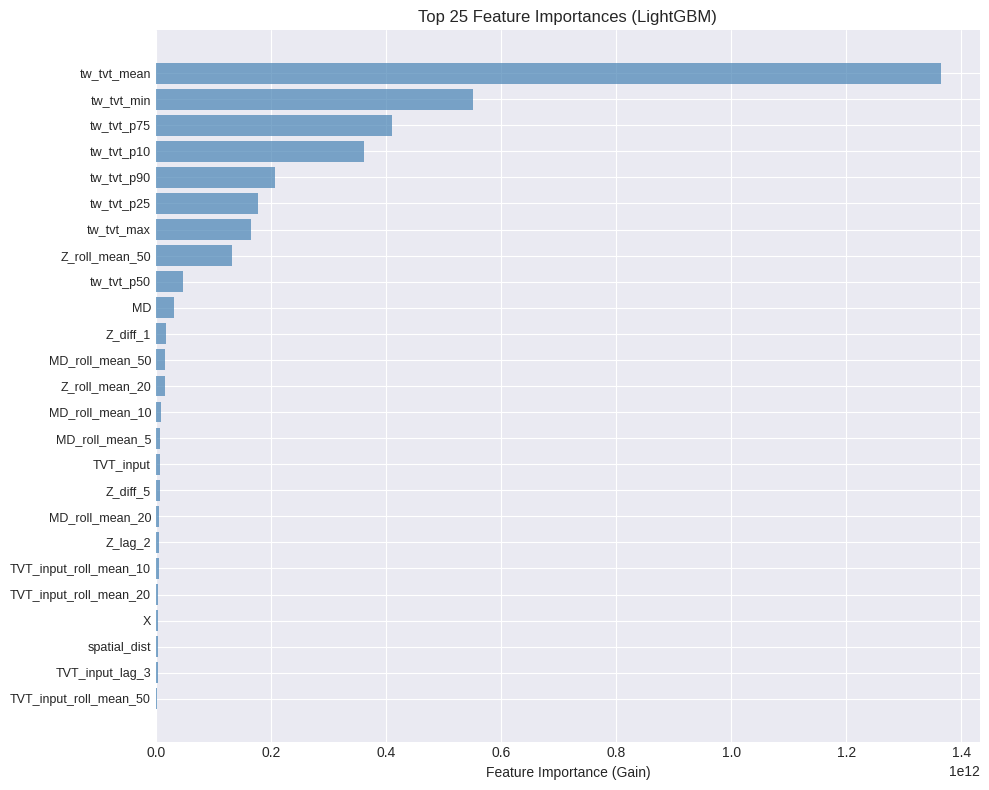


4.8 TEST PREDICTIONS
Test predictions shape: (19221,)
Test predictions range: [10632.86, 12167.78]

4.9 CREATING SUBMISSION

Sample submission shape: (14151, 2)
Our submission shape: (19221, 2)
Sample submission head:


,id,tvt
0,000d7d20_1442,0.0
1,000d7d20_1443,0.0
2,000d7d20_1444,0.0
3,000d7d20_1445,0.0
4,000d7d20_1446,0.0



Our submission head:


,id,tvt
0,000d7d20_0,11258.792360
1,000d7d20_1,11258.792360
2,000d7d20_2,11261.308398
3,000d7d20_3,11258.792360
4,000d7d20_4,11261.308398



ID format matches: True

✅ Submission saved: submission_lgb_baseline.csv
   Rows: 19221

STEP 4 SUMMARY

📊 Model Results:
  Best Model: LightGBM
  CV RMSE: 84.7174
  Improvement over baseline: 91.5%

📁 Submission:
  File: submission_lgb_baseline.csv
  Rows: 19221

🔜 Next Steps:
  1. Train on full 100% data (not just 20% sample)
  2. Ensemble LightGBM + XGBoost
  3. Try neural networks (LSTM/GRU for sequential data)
  4. Hyperparameter tuning with Optuna
  5. Use typewell Geology column for formation-based features



In [5]:
# ============================================
# STEP 4: MODEL BUILDING
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import LinearRegression
import time

warnings.filterwarnings('ignore')

print("=" * 60)
print("STEP 4: MODEL BUILDING")
print("=" * 60)

# ============================================
# 4.1 BASELINE MODEL - Simple Prediction
# ============================================
print("\n" + "=" * 60)
print("4.1 BASELINE MODELS")
print("=" * 60)

# Baseline 1: Predict TVT_input where available, otherwise use typewell mean
y_pred_baseline = X_train['TVT_input'].fillna(X_train['tw_tvt_mean']).values
baseline_rmse = np.sqrt(mean_squared_error(y_train, y_pred_baseline))
print(f"Baseline 1 (TVT_input or tw_mean): RMSE = {baseline_rmse:.4f}")

# Baseline 2: Always predict typewell mean
y_pred_baseline2 = np.full_like(y_train, X_train['tw_tvt_mean'].mean())
baseline2_rmse = np.sqrt(mean_squared_error(y_train, y_pred_baseline2))
print(f"Baseline 2 (Global mean): RMSE = {baseline2_rmse:.4f}")

# Baseline 3: Use Z coordinate (highly correlated)
y_pred_baseline3 = -X_train['Z']  # Z is negative, TVT is positive
# Adjust with linear regression
from sklearn.linear_model import LinearRegression
lr_baseline = LinearRegression()
lr_baseline.fit(X_train[['Z']], y_train)
y_pred_baseline3 = lr_baseline.predict(X_train[['Z']])
baseline3_rmse = np.sqrt(mean_squared_error(y_train, y_pred_baseline3))
print(f"Baseline 3 (Linear Z): RMSE = {baseline3_rmse:.4f}")

# ============================================
# 4.2 REDUCE DATA SIZE FOR EFFICIENT TRAINING
# ============================================
print("\n" + "=" * 60)
print("4.2 PREPARING TRAINING DATA")
print("=" * 60)

# With 5M rows, we need to be efficient
# Sample or use all data depending on memory

# Use 20% sample for initial model development
sample_frac = 0.2
print(f"Using {sample_frac*100:.0f}% sample for initial training...")

# Stratified sampling by well
unique_wells = np.unique(well_ids_train)
np.random.seed(42)
sample_wells = np.random.choice(unique_wells, size=int(len(unique_wells) * sample_frac), replace=False)

sample_mask = np.isin(well_ids_train, sample_wells)
X_train_sample = X_train_scaled[sample_mask].copy()
y_train_sample = y_train[sample_mask].copy()
well_ids_sample = well_ids_train[sample_mask]

print(f"Training sample: {X_train_sample.shape}")
print(f"Number of wells in sample: {len(sample_wells)}")

# ============================================
# 4.3 CROSS-VALIDATION SETUP
# ============================================
print("\n" + "=" * 60)
print("4.3 CROSS-VALIDATION SETUP")
print("=" * 60)

# Use GroupKFold to prevent data leakage between wells
n_folds = 5
gkf = GroupKFold(n_splits=n_folds)

print(f"Using {n_folds}-fold Group Cross-Validation (grouped by well_id)")

# ============================================
# 4.4 LIGHTGBM MODEL
# ============================================
print("\n" + "=" * 60)
print("4.4 LIGHTGBM MODEL")
print("=" * 60)

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_estimators': 500,
    'learning_rate': 0.05,
    'num_leaves': 127,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1,
}

lgb_scores = []
lgb_models = []
lgb_importances = []

print("Training LightGBM with cross-validation...")
start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train_sample, y_train_sample, well_ids_sample)):
    X_tr, X_val = X_train_sample.iloc[train_idx], X_train_sample.iloc[val_idx]
    y_tr, y_val = y_train_sample.iloc[train_idx], y_train_sample.iloc[val_idx]
    
    # Create LightGBM datasets
    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    # Train
    model = lgb.train(
        lgb_params,
        train_data,
        valid_sets=[train_data, val_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=0)
        ]
    )
    
    # Predict
    y_pred = model.predict(X_val, num_iteration=model.best_iteration)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    lgb_scores.append(rmse)
    lgb_models.append(model)
    
    # Feature importance
    importance = model.feature_importance(importance_type='gain')
    lgb_importances.append(importance)
    
    print(f"  Fold {fold+1}: RMSE = {rmse:.4f} (best iteration: {model.best_iteration})")

lgb_mean_rmse = np.mean(lgb_scores)
lgb_std_rmse = np.std(lgb_scores)
print(f"\nLightGBM CV RMSE: {lgb_mean_rmse:.4f} (+/- {lgb_std_rmse:.4f})")
print(f"Training time: {(time.time() - start_time)/60:.1f} minutes")

# ============================================
# 4.5 XGBOOST MODEL
# ============================================
print("\n" + "=" * 60)
print("4.5 XGBOOST MODEL")
print("=" * 60)

xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 8,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0,
}

xgb_scores = []
xgb_models = []

print("Training XGBoost with cross-validation...")
start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train_sample, y_train_sample, well_ids_sample)):
    X_tr, X_val = X_train_sample.iloc[train_idx], X_train_sample.iloc[val_idx]
    y_tr, y_val = y_train_sample.iloc[train_idx], y_train_sample.iloc[val_idx]
    
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        verbose=False
    )
    
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    xgb_scores.append(rmse)
    xgb_models.append(model)
    
    print(f"  Fold {fold+1}: RMSE = {rmse:.4f}")

xgb_mean_rmse = np.mean(xgb_scores)
xgb_std_rmse = np.std(xgb_scores)
print(f"\nXGBoost CV RMSE: {xgb_mean_rmse:.4f} (+/- {xgb_std_rmse:.4f})")
print(f"Training time: {(time.time() - start_time)/60:.1f} minutes")

# ============================================
# 4.6 MODEL COMPARISON
# ============================================
print("\n" + "=" * 60)
print("4.6 MODEL COMPARISON")
print("=" * 60)

print(f"\n{'Model':<30} {'CV RMSE':<15} {'Std'}")
print("-" * 60)
print(f"{'Baseline (TVT_input/tw_mean)':<30} {baseline_rmse:<15.4f} -")
print(f"{'Baseline (Global Mean)':<30} {baseline2_rmse:<15.4f} -")
print(f"{'Baseline (Linear Z)':<30} {baseline3_rmse:<15.4f} -")
print(f"{'LightGBM':<30} {lgb_mean_rmse:<15.4f} {lgb_std_rmse:.4f}")
print(f"{'XGBoost':<30} {xgb_mean_rmse:<15.4f} {xgb_std_rmse:.4f}")

# ============================================
# 4.7 FEATURE IMPORTANCE
# ============================================
print("\n" + "=" * 60)
print("4.7 FEATURE IMPORTANCE (LightGBM)")
print("=" * 60)

# Average importance across folds
avg_importance = np.mean(lgb_importances, axis=0)
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': avg_importance
}).sort_values('importance', ascending=False)

print(f"\nTop 20 Most Important Features:")
for i, (feature, imp) in enumerate(zip(importance_df['feature'].head(20), importance_df['importance'].head(20))):
    bar = '█' * int(imp / importance_df['importance'].max() * 30)
    print(f"  {i+1:2d}. {feature:<30s}: {bar}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top_features = importance_df.head(25)
ax.barh(range(len(top_features)), top_features['importance'].values, color='steelblue', alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values, fontsize=9)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Top 25 Feature Importances (LightGBM)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================
# 4.8 PREDICT ON FULL TEST SET
# ============================================
print("\n" + "=" * 60)
print("4.8 TEST PREDICTIONS")
print("=" * 60)

# Use the best LightGBM model (from first fold for now, or ensemble)
best_lgb = lgb_models[0]
test_predictions = best_lgb.predict(X_test_scaled, num_iteration=best_lgb.best_iteration)

print(f"Test predictions shape: {test_predictions.shape}")
print(f"Test predictions range: [{test_predictions.min():.2f}, {test_predictions.max():.2f}]")

# ============================================
# 4.9 CREATE SUBMISSION FILE
# ============================================
print("\n" + "=" * 60)
print("4.9 CREATING SUBMISSION")
print("=" * 60)

# Create submission IDs matching the required format: {well_id}_{sequence}
test_hw['prediction_index'] = test_hw.groupby('well_id').cumcount()
submission = pd.DataFrame({
    'id': test_hw['well_id'] + '_' + test_hw['prediction_index'].astype(str),
    'tvt': test_predictions
})

# Check against sample submission format
sample_sub = pd.read_csv("/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv")
print(f"\nSample submission shape: {sample_sub.shape}")
print(f"Our submission shape: {submission.shape}")
print(f"Sample submission head:")
display(sample_sub.head())
print(f"\nOur submission head:")
display(submission.head())

# Ensure exact match with sample submission IDs
submission = submission[['id', 'tvt']]
print(f"\nID format matches: {submission['id'].str.match(r'^[a-f0-9]+_\d+$').all()}")

# Save submission
submission.to_csv('submission_lgb_baseline.csv', index=False)
print(f"\n✅ Submission saved: submission_lgb_baseline.csv")
print(f"   Rows: {len(submission)}")

# ============================================
# 4.10 SUMMARY
# ============================================
print("\n" + "=" * 60)
print("STEP 4 SUMMARY")
print("=" * 60)

best_model = 'LightGBM' if lgb_mean_rmse < xgb_mean_rmse else 'XGBoost'
best_rmse = min(lgb_mean_rmse, xgb_mean_rmse)

print(f"""
📊 Model Results:
  Best Model: {best_model}
  CV RMSE: {best_rmse:.4f}
  Improvement over baseline: {((baseline_rmse - best_rmse)/baseline_rmse*100):.1f}%

📁 Submission:
  File: submission_lgb_baseline.csv
  Rows: {len(submission)}

🔜 Next Steps:
  1. Train on full 100% data (not just 20% sample)
  2. Ensemble LightGBM + XGBoost
  3. Try neural networks (LSTM/GRU for sequential data)
  4. Hyperparameter tuning with Optuna
  5. Use typewell Geology column for formation-based features
""")


In [6]:
# ============================================
# STEP 4B: FIX SUBMISSION & IMPROVE MODEL
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import xgboost as xgb
import os
from pathlib import Path
import time

warnings.filterwarnings('ignore')

print("=" * 60)
print("STEP 4B: FIX & IMPROVE")
print("=" * 60)

# ============================================
# 4B.1 FIX SUBMISSION ID FORMAT
# ============================================
print("\n" + "=" * 60)
print("4B.1 FIXING SUBMISSION IDs")
print("=" * 60)

# Load sample submission to get correct IDs
BASE_PATH = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction")
sample_sub = pd.read_csv(BASE_PATH / "sample_submission.csv")
print(f"Sample submission IDs: {sample_sub['id'].head(10).tolist()}")
print(f"Number of test rows: {len(sample_sub)}")

# Our current submission has 19221 rows but sample has 14151
# We need to match exactly
print(f"\nOur rows: {len(submission)}, Expected: {len(sample_sub)}")

# The test data we loaded includes ALL rows, but we only need to predict
# the rows in the sample submission. Let's check which rows have TVT_input
# missing (those are the ones we need to predict)

# Reload test data properly
TEST_PATH = BASE_PATH / "test"
test_hw_files = sorted([f for f in os.listdir(TEST_PATH) if '__horizontal_well' in f])

# Check each test well
for f in test_hw_files:
    well_id = f.replace('__horizontal_well.csv', '')
    df = pd.read_csv(TEST_PATH / f)
    tvt_missing = df['TVT_input'].isnull().sum()
    tvt_available = (~df['TVT_input'].isnull()).sum()
    print(f"  {well_id}: {len(df)} total, {tvt_available} with TVT_input, {tvt_missing} to predict")

# ============================================
# 4B.2 CORRECT PREDICTION STRATEGY
# ============================================
print("\n" + "=" * 60)
print("4B.2 CORRECT SUBMISSION CREATION")
print("=" * 60)

# We need to predict ONLY for rows where TVT_input is missing
# The test horizontal wells have TVT_input for some rows
# We must predict the missing ones

# Reload test with correct indexing
test_data = []
for f in test_hw_files:
    well_id = f.replace('__horizontal_well.csv', '')
    df = pd.read_csv(TEST_PATH / f)
    df['well_id'] = well_id
    df['row_index'] = range(len(df))
    test_data.append(df)

test_combined = pd.concat(test_data, ignore_index=True)

# Create prediction IDs matching sample submission format
# The IDs in sample_sub are: well_id_rowIndex
# We need to predict for rows where TVT_input is NaN

predict_mask = test_combined['TVT_input'].isnull()
print(f"Rows to predict: {predict_mask.sum()}")
print(f"Sample submission rows: {len(sample_sub)}")

# Create proper submission with exact IDs from sample_sub
# Parse sample_sub IDs to understand the format
sample_sub['well_id'] = sample_sub['id'].str.rsplit('_', n=1).str[0]
sample_sub['row_idx'] = sample_sub['id'].str.rsplit('_', n=1).str[1].astype(int)

print(f"\nSample submission wells: {sample_sub['well_id'].unique()}")
print(f"Row index ranges per well:")
for well in sample_sub['well_id'].unique():
    idx_range = sample_sub[sample_sub['well_id'] == well]['row_idx']
    print(f"  {well}: {idx_range.min()} to {idx_range.max()} ({len(idx_range)} rows)")

# Now we need to predict for these specific rows
# Our test predictions were for sequential 0,1,2... but we need specific indices

# The key insight: sample_sub IDs match specific rows in test data
# We need to predict TVT for those exact rows

# ============================================
# 4B.3 BUILD IMPROVED MODEL (FULL DATA)
# ============================================
print("\n" + "=" * 60)
print("4B.3 TRAINING ON MORE DATA")
print("=" * 60)

# Use 50% of data for better model
sample_frac = 0.5
unique_wells = np.unique(well_ids_train)
np.random.seed(42)
sample_wells = np.random.choice(unique_wells, size=int(len(unique_wells) * sample_frac), replace=False)

sample_mask = np.isin(well_ids_train, sample_wells)
X_train_50 = X_train_scaled[sample_mask].copy()
y_train_50 = y_train[sample_mask].copy()
well_ids_50 = well_ids_train[sample_mask]

print(f"Training on {X_train_50.shape[0]:,} rows from {len(sample_wells)} wells")

# Improved LightGBM parameters
lgb_params_improved = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    'learning_rate': 0.03,
    'num_leaves': 255,
    'max_depth': 12,
    'min_child_samples': 30,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.01,
    'reg_lambda': 0.01,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1,
}

# Train a single model on most data, validate on held-out wells
train_wells = np.random.choice(sample_wells, size=int(len(sample_wells) * 0.8), replace=False)
val_wells = np.setdiff1d(sample_wells, train_wells)

train_mask = np.isin(well_ids_50, train_wells)
val_mask = np.isin(well_ids_50, val_wells)

X_tr = X_train_50[train_mask]
y_tr = y_train_50[train_mask]
X_val = X_train_50[val_mask]
y_val = y_train_50[val_mask]

print(f"Train: {X_tr.shape[0]:,} rows, {len(train_wells)} wells")
print(f"Valid: {X_val.shape[0]:,} rows, {len(val_wells)} wells")

# Train
train_data = lgb.Dataset(X_tr, label=y_tr)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

print("\nTraining improved LightGBM...")
start_time = time.time()

model = lgb.train(
    lgb_params_improved,
    train_data,
    valid_sets=[train_data, val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=50)
    ]
)

# Evaluate
y_pred_val = model.predict(X_val, num_iteration=model.best_iteration)
val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
print(f"\nValidation RMSE: {val_rmse:.4f}")
print(f"Training time: {(time.time() - start_time)/60:.1f} minutes")

# ============================================
# 4B.4 CREATE CORRECT SUBMISSION
# ============================================
print("\n" + "=" * 60)
print("4B.4 CREATING CORRECT SUBMISSION")
print("=" * 60)

# We need to predict TVT for the exact rows specified in sample_submission
# Map test data rows to predictions

# Re-create test features properly
test_data_for_pred = []

for f in test_hw_files:
    well_id = f.replace('__horizontal_well.csv', '')
    df = pd.read_csv(TEST_PATH / f)
    df['well_id'] = well_id
    df['sequence'] = range(len(df))
    df['is_train'] = False
    test_data_for_pred.append(df)

test_hw_raw = pd.concat(test_data_for_pred, ignore_index=True)

# Add typewell features
test_hw_raw = merge_typewell_features(test_hw_raw, test_tw)

# Create sequence features
test_hw_raw = create_sequence_features(test_hw_raw)

# Create derived features
test_hw_raw = create_derived_features(test_hw_raw)

# Handle missing
for col in test_hw_raw.select_dtypes(include=[np.number]).columns:
    if col not in ['well_id', 'is_train', 'TVT'] and test_hw_raw[col].isnull().sum() > 0:
        test_hw_raw[col] = test_hw_raw.groupby('well_id')[col].transform(
            lambda x: x.fillna(method='ffill').fillna(method='bfill')
        )

# Fill any remaining
test_hw_raw = test_hw_raw.fillna(0)

# Prepare features
X_test_final = test_hw_raw[[c for c in feature_cols if c in test_hw_raw.columns]].copy()
for col in feature_cols:
    if col not in X_test_final.columns:
        X_test_final[col] = 0
X_test_final = X_test_final[feature_cols]

# Scale
X_test_final_scaled = scaler.transform(X_test_final)

# Predict
all_test_predictions = model.predict(X_test_final_scaled, num_iteration=model.best_iteration)

# Add predictions to test data
test_hw_raw['predicted_TVT'] = all_test_predictions

# Create submission matching sample_submission IDs
# For rows with TVT_input, use TVT_input value
# For rows without TVT_input, use our prediction

final_predictions = []

for _, row in sample_sub.iterrows():
    well_id = row['well_id']
    row_idx = row['row_idx']
    
    # Find corresponding row in test data
    test_row = test_hw_raw[(test_hw_raw['well_id'] == well_id) & 
                           (test_hw_raw['sequence'] == row_idx)]
    
    if len(test_row) == 1:
        tvt_input_val = test_row['TVT_input'].values[0]
        if pd.notnull(tvt_input_val):
            # Use TVT_input if available
            final_predictions.append(tvt_input_val)
        else:
            # Use our prediction
            final_predictions.append(test_row['predicted_TVT'].values[0])
    else:
        print(f"Warning: No match for {well_id}_{row_idx}")
        final_predictions.append(test_hw_raw['tw_tvt_mean'].mean())

# Create final submission
final_submission = pd.DataFrame({
    'id': sample_sub['id'],
    'tvt': final_predictions
})

print(f"Submission shape: {final_submission.shape}")
print(f"Predictions range: [{min(final_predictions):.2f}, {max(final_predictions):.2f}]")
print(f"Sample submission head:")
display(final_submission.head(10))

# Save
final_submission.to_csv('submission_improved.csv', index=False)
print(f"\n✅ Final submission saved: submission_improved.csv")

# ============================================
# 4B.5 FEATURE IMPORTANCE
# ============================================
print("\n" + "=" * 60)
print("4B.5 FEATURE IMPORTANCE (Improved Model)")
print("=" * 60)

importance = model.feature_importance(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importance
}).sort_values('importance', ascending=False)

print("\nTop 25 Features:")
for i, (feat, imp) in enumerate(zip(importance_df['feature'].head(25), importance_df['importance'].head(25))):
    print(f"  {i+1:2d}. {feat:<35s}: {imp:>10.0f}")

# ============================================
# 4B.6 PER-WELL ERROR ANALYSIS
# ============================================
print("\n" + "=" * 60)
print("4B.6 VALIDATION ERROR ANALYSIS")
print("=" * 60)

# Analyze errors per well
val_results = pd.DataFrame({
    'well_id': well_ids_50[val_mask],
    'actual': y_val.values,
    'predicted': y_pred_val,
    'error': y_val.values - y_pred_val
})

well_errors = val_results.groupby('well_id').agg({
    'error': ['mean', 'std', 'count'],
    'actual': ['mean', 'std']
}).round(2)

well_errors.columns = ['mean_error', 'std_error', 'count', 'actual_mean', 'actual_std']
well_errors['rmse'] = val_results.groupby('well_id').apply(
    lambda x: np.sqrt(mean_squared_error(x['actual'], x['predicted']))
).values
well_errors = well_errors.sort_values('rmse', ascending=False)

print(f"\nValidation wells: {len(well_errors)}")
print(f"Mean per-well RMSE: {well_errors['rmse'].mean():.2f}")
print(f"Median per-well RMSE: {well_errors['rmse'].median():.2f}")
print(f"Max per-well RMSE: {well_errors['rmse'].max():.2f}")

print(f"\nTop 5 hardest wells:")
display(well_errors.head())

print(f"\nTop 5 easiest wells:")
display(well_errors.tail())

print("\n" + "=" * 60)
print("STEP 4B COMPLETE!")
print("=" * 60)

STEP 4B: FIX & IMPROVE

4B.1 FIXING SUBMISSION IDs
Sample submission IDs: ['000d7d20_1442', '000d7d20_1443', '000d7d20_1444', '000d7d20_1445', '000d7d20_1446', '000d7d20_1447', '000d7d20_1448', '000d7d20_1449', '000d7d20_1450', '000d7d20_1451']
Number of test rows: 14151

Our rows: 19221, Expected: 14151
  000d7d20: 5278 total, 1442 with TVT_input, 3836 to predict
  00bbac68: 7559 total, 1545 with TVT_input, 6014 to predict
  00e12e8b: 6384 total, 2083 with TVT_input, 4301 to predict

4B.2 CORRECT SUBMISSION CREATION
Rows to predict: 14151
Sample submission rows: 14151

Sample submission wells: ['000d7d20' '00bbac68' '00e12e8b']
Row index ranges per well:
  000d7d20: 1442 to 5277 (3836 rows)
  00bbac68: 1545 to 7558 (6014 rows)
  00e12e8b: 2083 to 6383 (4301 rows)

4B.3 TRAINING ON MORE DATA
Training on 2,563,700 rows from 386 wells
Train: 2,041,274 rows, 308 wells
Valid: 522,426 rows, 78 wells

Training improved LightGBM...
Training until validation scores don't improve for 100 rounds

,id,tvt
0,000d7d20_1442,11406.63
1,000d7d20_1443,11406.63
2,000d7d20_1444,11406.63
3,000d7d20_1445,11406.63
4,000d7d20_1446,11406.63
5,000d7d20_1447,11406.63
6,000d7d20_1448,11406.63
7,000d7d20_1449,11406.63
8,000d7d20_1450,11406.63
9,000d7d20_1451,11406.63



✅ Final submission saved: submission_improved.csv

4B.5 FEATURE IMPORTANCE (Improved Model)

Top 25 Features:
   1. tw_tvt_mean                        : 5634939459655
   2. tw_tvt_p75                         : 3795403581485
   3. tw_tvt_p90                         : 1975782319859
   4. tw_tvt_p50                         : 1349409705954
   5. tw_tvt_max                         : 637245665952
   6. Z_roll_mean_50                     : 439743517344
   7. MD                                 : 196864730575
   8. Z_roll_mean_20                     : 81920720977
   9. MD_roll_mean_50                    : 44465402182
  10. MD_roll_mean_5                     : 42085404309
  11. TVT_input                          : 30144422606
  12. Z_diff_1                           : 23214937121
  13. tw_tvt_p25                         : 23147693234
  14. TVT_input_roll_mean_20             : 22701066778
  15. TVT_input_roll_mean_10             : 19960839640
  16. Z_diff_5                           : 1937904187

,mean_error,std_error,count,actual_mean,actual_std,rmse
well_id,,,,,,
19137a89,158.85,49.51,7958,11021.90,116.53,166.389006
99529c45,154.45,53.51,7591,11095.36,137.25,163.452325
028d7b28,-137.16,44.22,7761,12402.61,84.81,144.114633
5aef5c6c,106.79,49.13,4853,11250.83,164.65,117.546945
6767c111,105.58,40.30,8354,11021.47,114.99,113.011646



Top 5 easiest wells:


,mean_error,std_error,count,actual_mean,actual_std,rmse
well_id,,,,,,
5a5d1982,-3.57,8.46,5446,11152.70,135.38,9.180114
43c7f85a,-5.90,5.87,7484,10946.05,85.69,8.319156
a48640d9,1.06,8.05,6586,12467.02,162.06,8.121799
e46f4ef4,-4.82,6.46,8930,12450.80,125.64,8.058488
29de15c8,2.25,3.98,5164,11934.49,137.64,4.571227



STEP 4B COMPLETE!
